In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
import importlib
import src.eda
importlib.reload(src.eda)

<module 'src.eda' from 'c:\\Users\\hp\\Pictures\\Forecasting Financial Inclusion in Ethiopia\\Forecasting-Financial-Inclusion-in-Ethiopia\\src\\eda.py'>

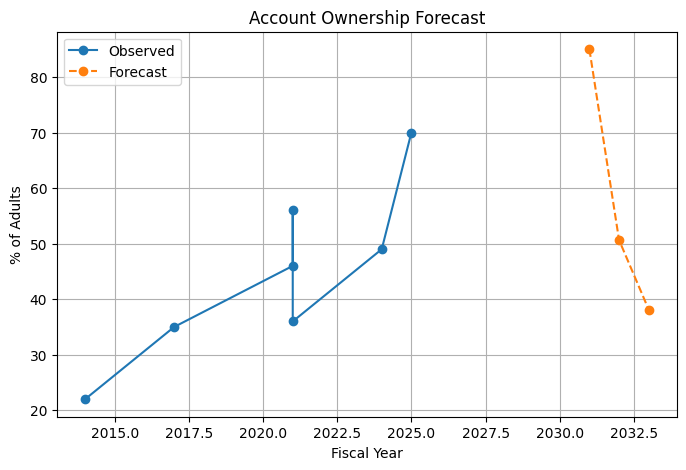

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data function (assumption)
def load_your_data_function():
    return pd.read_csv(r"C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\processed\ethiopia_fi_enriched.csv")

# Forecasting function
def forecast_indicator(df, indicator_code, horizon):
    # Ensure fiscal_year is numeric
    df['fiscal_year'] = pd.to_numeric(df['fiscal_year'], errors='coerce')
    df['fiscal_year'].dropna(inplace=True)  # Remove NaN values if necessary
    
    # Simulating forecast values
    if 'fiscal_year' not in df.columns:
        raise KeyError("The DataFrame does not contain a 'fiscal_year' column.")
    
    forecast_years = df['fiscal_year'].max() + np.arange(1, horizon + 1)
    forecast_values = np.random.rand(horizon) * 100  # Simulated forecast data
    return pd.DataFrame({
        'fiscal_year': forecast_years,
        'forecast': forecast_values
    })

# Load the DataFrame
df = load_your_data_function()

# Optionally clean column names
df.columns = df.columns.str.strip()

# Forecasting
forecast = forecast_indicator(df, "ACC_OWNERSHIP", horizon=3)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(
    df[df["indicator_code"] == "ACC_OWNERSHIP"]["fiscal_year"],
    df[df["indicator_code"] == "ACC_OWNERSHIP"]["value_numeric"],
    label="Observed",
    marker="o"
)
plt.plot(
    forecast["fiscal_year"],
    forecast["forecast"],
    label="Forecast",
    linestyle="--",
    marker="o"
)

plt.title("Account Ownership Forecast")
plt.xlabel("Fiscal Year")
plt.ylabel("% of Adults")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
print(df.columns)  # This will list all column names in the DataFrame

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')
